# RNN Model 

## Data inspection and preparation

In [26]:
# imports
import scipy.io as sio
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import matplotlib
import itertools
import pandas as pd
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


In [27]:
# Load the .mat file
data = sio.loadmat('../data/Xtrain.mat')
# Inspect the keys 
print(data.keys())



dict_keys(['__header__', '__version__', '__globals__', 'Xtrain'])


In [28]:
test = sio.loadmat('../data/Xtest.mat')
print(test.keys())

dict_keys(['__header__', '__version__', '__globals__', 'Xtest'])


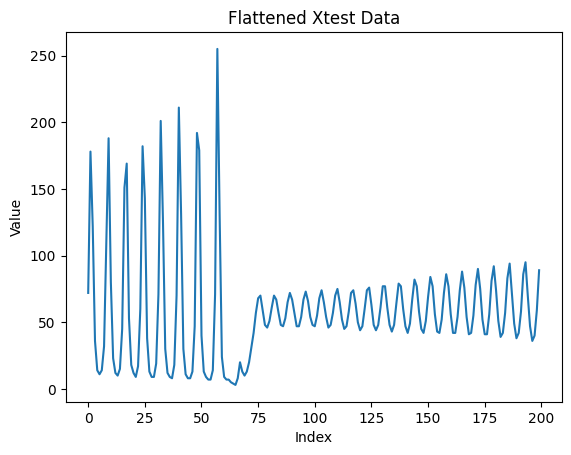

In [29]:
# plot flattened data
plt.plot(test['Xtest'].flatten())
plt.title('Flattened Xtest Data')
plt.xlabel('Index')
plt.ylabel('Value')
plt.show()

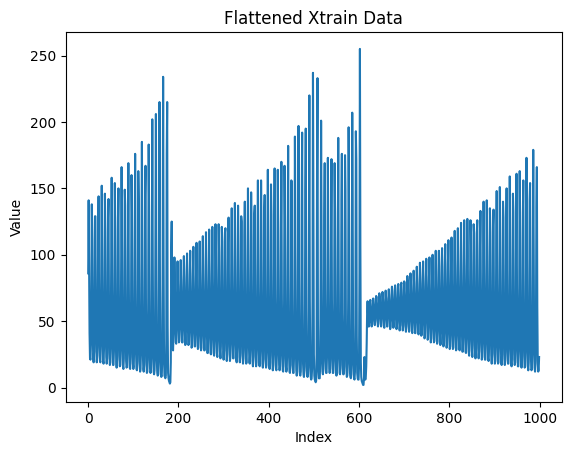

In [30]:
# plot flattened data
plt.plot(data['Xtrain'].flatten())
plt.title('Flattened Xtrain Data')
plt.xlabel('Index')
plt.ylabel('Value')
plt.show()

In [31]:
# create extra datapoint by interpolation
extra_data = (data['Xtrain'][:-1] + data['Xtrain'][1:]) / 2
X_combined = np.empty((len(data['Xtrain']) + len(extra_data),), dtype=data['Xtrain'].dtype)
X_combined[0::2] = data['Xtrain'].flatten()
X_combined[1::2] = extra_data.flatten()
print("Total samples after interpolation:", len(X_combined))

Total samples after interpolation: 1999


In [32]:
# # plot extra data points
# plt.plot(X_combined)
# plt.title('Combined Xtrain Data with Interpolation')
# plt.xlabel('Index')
# plt.ylabel('Value')
# plt.show()

In [33]:
# reshape data
X_raw = data['Xtrain'].flatten()  # make 1D
print("Total samples:", len(X_raw))



Total samples: 1000


## Creating datasets

In [34]:
def create_dataset(X, time_steps=1):
    """
    Create sequences of data for RNN input.
    Args:
        X (array-like): The input data.
        time_steps (int): The number of time steps in each sequence.
    Returns:
        tuple: A tuple containing the sequences (Xs) and the corresponding targets (ys).
    """
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        v = X[i:(i + time_steps)]
        Xs.append(v)
        ys.append(X[i + time_steps])
    return np.array(Xs), np.array(ys)

In [35]:
# build raw datasets without training test split
scaler = MinMaxScaler() # to train RNN with more stable
scaler.fit(X_raw.reshape(-1, 1))
X_scaled_raw = scaler.transform(X_raw.reshape(-1, 1)).flatten()
datasets_raw = {}
for i in [1, 2, 5, 10]:
    X_i, Y_i = create_dataset(X_scaled_raw, i)
    X_i = X_i.reshape(X_i.shape[0], X_i.shape[1], 1)
    
    datasets_raw[i] = {
        'X_train': X_i,
        'Y_train': Y_i, 
    }
    print(f"Window size {i}: train={X_i.shape}")

scaler.fit(X_combined.reshape(-1, 1))
X_scaled_combined = scaler.transform(X_combined.reshape(-1, 1)).flatten()

# Create datasets for each window size and store in dicts
datasets = {}

for i in [1, 2, 5, 10]:
    X_i, Y_i = create_dataset(X_scaled_combined, i)
    X_i = X_i.reshape(X_i.shape[0], X_i.shape[1], 1)
    datasets[i] = {
        'X_train': X_i, 
        'Y_train': Y_i, 
    }
    print(f"Window size {i}: train={X_i.shape}")


Window size 1: train=(999, 1, 1)
Window size 2: train=(998, 2, 1)
Window size 5: train=(995, 5, 1)
Window size 10: train=(990, 10, 1)
Window size 1: train=(1998, 1, 1)
Window size 2: train=(1997, 2, 1)
Window size 5: train=(1994, 5, 1)
Window size 10: train=(1989, 10, 1)


In [36]:
# # Build raw datasets
# scaler = MinMaxScaler() # to train RNN with more stable
# scaler.fit(X_raw.reshape(-1, 1))
# X_scaled_raw = scaler.transform(X_raw.reshape(-1, 1)).flatten()

# datasets_raw = {}
# for i in [1, 2, 5, 10]:
#     X_i, Y_i = create_dataset(X_scaled_raw, i)
#     X_i = X_i.reshape(X_i.shape[0], X_i.shape[1], 1)
#     split = int(len(X_i) * 0.8)
#     datasets_raw[i] = {
#         'X_train': X_i[:split], 'X_test': X_i[split:],
#         'Y_train': Y_i[:split], 'Y_test': Y_i[split:],
#     }
#     print(f"Window size {i}: train={X_i[:split].shape}, test={X_i[split:].shape}")

In [37]:
# # interpolated dataset

# # Normalize data 
# # scaler = MinMaxScaler() # to train RNN with more stable
# scaler.fit(X_combined.reshape(-1, 1))
# X_scaled_combined = scaler.transform(X_combined.reshape(-1, 1)).flatten()

# # Create datasets for each window size and store in dicts
# datasets = {}


# for i in [1, 2, 5, 10]:
#     X_i, Y_i = create_dataset(X_scaled_combined, i)
#     X_i = X_i.reshape(X_i.shape[0], X_i.shape[1], 1)
#     split = int(len(X_i) * 0.8)
#     datasets[i] = {
#         'X_train': X_i[:split], 'X_test': X_i[split:],
#         'Y_train': Y_i[:split], 'Y_test': Y_i[split:],
#     }
#     print(f"Window size {i}: train={X_i[:split].shape}, test={X_i[split:].shape}")


## Grid Search for Optimal Hyperparameters

Search over `window_size`, `rnn_units`, `learning_rate`, and `batch_size` using the raw dataset.

In [38]:
# param_grid = {
#     'window_size':   [1, 2, 5, 10],
#     'rnn_units':     [20, 50, 100],
#     'learning_rate': [0.001, 0.01],
#     'batch_size':    [32, 64],
# }

# gs_results_raw = []
# gs_early_stop = tf.keras.callbacks.EarlyStopping(
#     monitor='val_loss', patience=5, restore_best_weights=True
# )

# keys, values = zip(*param_grid.items())
# total = 1
# for v in values:
#     total *= len(v)
# print(f"\nRunning {total} combinations on raw data...\n")

# for idx, combo in enumerate(itertools.product(*values), 1):
#     params = dict(zip(keys, combo))
#     ws = params['window_size']
#     d = datasets_raw[ws]

#     model = Sequential([
#         tf.keras.Input(shape=(ws, 1)),
#         SimpleRNN(params['rnn_units'], activation='tanh'),
#         Dense(1),
#     ])
#     model.compile(
#         optimizer=tf.keras.optimizers.Adam(learning_rate=params['learning_rate']),
#         loss='mse',
#         metrics=['mae'],
#     )
#     hist = model.fit(
#         d['X_train'], d['Y_train'],
#         epochs=100, batch_size=params['batch_size'], verbose=0,
#         validation_split=0.2,
#         # validation_data=(d['X_test'], d['Y_test']),
#         callbacks=[gs_early_stop],
#     )
#     val_loss = min(hist.history['val_loss'])
#     val_mae  = min(hist.history['val_mae'])
#     gs_results_raw.append({
#         **params,
#         'val_loss':   val_loss,
#         'val_mae':    val_mae,
#         'epochs_run': len(hist.history['val_loss']),
#     })
#     print(f"[{idx:>2}/{total}] ws={ws}, units={params['rnn_units']:>3}, "
#           f"lr={params['learning_rate']}, bs={params['batch_size']:>2} "
#           f"-> val_loss={val_loss:.4f}, val_mae={val_mae:.4f}")

# gs_df_raw = pd.DataFrame(gs_results_raw).sort_values('val_loss').reset_index(drop=True)
# print("\nTop 10 configurations (raw):")
# print(gs_df_raw.head(10).to_string(index=False))

In [39]:
# fig, axes = plt.subplots(2, 3, figsize=(16, 10))
# fig.suptitle('Grid Search Results (Raw Data)', fontsize=14)

# # 1. Top 15 configs ranked by val_loss
# ax = axes[0, 0]
# top15 = gs_df_raw.head(15).copy()
# labels = [f"ws={r.window_size}, u={r.rnn_units}\nlr={r.learning_rate}, bs={r.batch_size}"
#           for r in top15.itertuples()]
# ax.barh(range(len(top15)), top15['val_loss'], color='steelblue')
# ax.set_yticks(range(len(top15)))
# ax.set_yticklabels(labels, fontsize=7)
# ax.invert_yaxis()
# ax.set_xlabel('val_loss (MSE)')
# ax.set_title('Top 15 Configurations')

# # 2–5. Effect of each individual parameter on val_loss
# for ax, param in zip(
#     [axes[0, 1], axes[0, 2], axes[1, 0], axes[1, 1]],
#     ['window_size', 'rnn_units', 'learning_rate', 'batch_size'],
# ):
#     grouped = gs_df_raw.groupby(param)['val_loss'].agg(['mean', 'min', 'max']).reset_index()
#     x = range(len(grouped))
#     ax.bar(x, grouped['mean'], color='steelblue', alpha=0.7, label='mean')
#     ax.errorbar(x, grouped['mean'],
#                 yerr=[grouped['mean'] - grouped['min'], grouped['max'] - grouped['mean']],
#                 fmt='none', color='black', capsize=4, label='min/max')
#     ax.set_xticks(x)
#     ax.set_xticklabels(grouped[param])
#     ax.set_xlabel(param)
#     ax.set_ylabel('val_loss (MSE)')
#     ax.set_title(f'Effect of {param}')
#     ax.legend(fontsize=8)

# # 6. Heatmap: window_size × rnn_units (mean val_loss)
# ax = axes[1, 2]
# pivot = gs_df_raw.groupby(['window_size', 'rnn_units'])['val_loss'].mean().unstack()
# sns.heatmap(pivot, ax=ax, annot=True, fmt='.4f', cmap='YlOrRd_r',
#             cbar_kws={'label': 'mean val_loss'})
# ax.set_title('Mean val_loss: window_size × rnn_units')
# ax.set_xlabel('rnn_units')
# ax.set_ylabel('window_size')

# plt.tight_layout()
# plt.show()

# best = gs_df_raw.iloc[0]
# print(f"\nBest config: window_size={int(best.window_size)}, rnn_units={int(best.rnn_units)}, "
#       f"lr={best.learning_rate}, batch_size={int(best.batch_size)}")
# print(f"  val_loss={best.val_loss:.4f}, val_mae={best.val_mae:.4f}")

In [40]:
# # only show effect of window size plot
# fig, ax = plt.subplots(figsize=(8, 5))
# grouped = gs_df_raw.groupby('window_size')['val_loss'].agg(['mean', 'min', 'max']).reset_index()
# x = range(len(grouped))
# ax.bar(x, grouped['mean'], color='steelblue', alpha=0.7, label='mean')
# ax.errorbar(x, grouped['mean'],
#             yerr=[grouped['mean'] - grouped['min'], grouped['max'] - grouped['mean']],
#             fmt='none', color='black', capsize=4, label='min/max')
# ax.set_xticks(x)
# ax.set_xticklabels(grouped['window_size'])
# ax.set_xlabel('window_size')
# ax.set_ylabel('val_loss (MSE)')
# ax.set_title('Effect of window_size on val_loss')
# ax.legend(fontsize=8)
# plt.tight_layout()
# plt.show()

## Final Model with Best Configuration

In [41]:
# # Train one final model per window size using best config from grid search
# final_models = {}
# final_hists  = {}

# for ws in [2, 10]:
#     best = gs_df_raw[gs_df_raw['window_size'] == ws].sort_values('val_loss').iloc[0]
#     d    = datasets_raw[ws]

#     model = Sequential([
#         tf.keras.Input(shape=(ws, 1)),
#         SimpleRNN(int(best.rnn_units), activation='tanh'),
#         Dense(1),
#     ])
#     model.compile(
#         optimizer=tf.keras.optimizers.Adam(learning_rate=best.learning_rate),
#         loss='mse',
#         metrics=['mae'],
#     )
#     early_stop = tf.keras.callbacks.EarlyStopping(
#         monitor='val_loss', patience=10, restore_best_weights=True
#     )
#     hist = model.fit(
#         d['X_train'], d['Y_train'],
#         epochs=200, batch_size=int(best.batch_size),
#         validation_split=0.2, verbose=0,
#         callbacks=[early_stop],
#     )
#     final_models[ws] = model
#     final_hists[ws]  = hist

#     print(f"ws={ws}: units={int(best.rnn_units)}, lr={best.learning_rate}, "
#           f"bs={int(best.batch_size)} -> stopped at epoch {len(hist.history['val_loss'])}, "
#           f"best val_loss={min(hist.history['val_loss'])}")
#     model.save(f'best_rnn_ws{ws}.keras')

# # Loss curves side by side
# fig, axes = plt.subplots(1, 2, figsize=(12, 4))
# fig.suptitle('Final Model Loss Curves', fontsize=12)
# for ax, ws in zip(axes, [2, 10]):
#     hist = final_hists[ws]
#     ax.plot(hist.history['loss'],     label='Train loss')
#     ax.plot(hist.history['val_loss'], label='Val loss')
#     ax.set_title(f'window_size={ws}')
#     ax.set_xlabel('Epoch')
#     ax.set_ylabel('MSE')
#     ax.legend()
# plt.tight_layout()
# plt.show()

In [42]:

final_models = {                                                                                                                                                                                         
      2:  tf.keras.models.load_model('best_rnn_ws2.keras')                                                                                                                                              
    #   10: tf.keras.models.load_model('best_rnn_ws10.keras'),                                                                                                                                               
  }   

Model          1-step MSE   1-step MAE   200-step MSE   200-step MAE
----------------------------------------------------------------------
RNN ws=2           93.2228       5.9703      1906.8091        28.9150
naive mean                                  1672.2157        27.7327


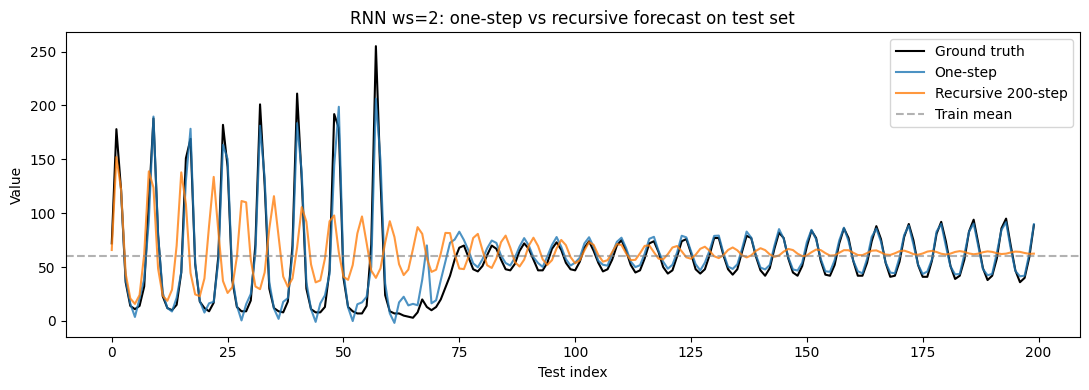

In [43]:
# Test-set evaluation: one-step vs recursive 200-step vs naive baseline
# Refit the scaler on the raw training data (the interpolated-dataset cell
# above overwrote the scaler in memory).
scaler_raw = MinMaxScaler()
scaler_raw.fit(X_raw.reshape(-1, 1))

X_test_raw = test['Xtest'].flatten()
X_test_scaled = scaler_raw.transform(X_test_raw.reshape(-1, 1)).flatten()
X_train_scaled = scaler_raw.transform(X_raw.reshape(-1, 1)).flatten()

def recursive_forecast(model, ws, history_scaled, horizon=200):
    cur = history_scaled[-ws:].reshape(1, ws, 1)
    preds_s = []
    for _ in range(horizon):
        p = model.predict(cur, verbose=0)
        preds_s.append(p[0, 0])
        cur = np.append(cur[:, 1:, :], p.reshape(1, 1, 1), axis=1)
    return scaler_raw.inverse_transform(np.array(preds_s).reshape(-1, 1)).flatten()

def one_step_forecast(model, ws, test_scaled):
    Xs, Ys = [], []
    for i in range(len(test_scaled) - ws):
        Xs.append(test_scaled[i:i+ws])
        Ys.append(test_scaled[i+ws])
    Xs = np.array(Xs).reshape(-1, ws, 1)
    preds = model.predict(Xs, verbose=0).flatten()
    y_pred = scaler_raw.inverse_transform(preds.reshape(-1, 1)).flatten()
    y_true = scaler_raw.inverse_transform(np.array(Ys).reshape(-1, 1)).flatten()
    return y_true, y_pred

rows = []
for ws, model in final_models.items():
    y_true_1s, y_pred_1s = one_step_forecast(model, ws, X_test_scaled)
    os_mse = mean_squared_error(y_true_1s, y_pred_1s)
    os_mae = mean_absolute_error(y_true_1s, y_pred_1s)

    y_pred_rec = recursive_forecast(model, ws, X_train_scaled)
    rec_mse = mean_squared_error(X_test_raw, y_pred_rec)
    rec_mae = mean_absolute_error(X_test_raw, y_pred_rec)

    rows.append((ws, os_mse, os_mae, rec_mse, rec_mae))

# naive baseline: predict the training mean for every step
baseline = np.full(len(X_test_raw), X_raw.mean())
base_mse = mean_squared_error(X_test_raw, baseline)
base_mae = mean_absolute_error(X_test_raw, baseline)

print(f"{'Model':<12} {'1-step MSE':>12} {'1-step MAE':>12} {'200-step MSE':>14} {'200-step MAE':>14}")
print("-" * 70)
for ws, om, oa, rm, ra in rows:
    print(f"RNN ws={ws:<6} {om:>12.4f} {oa:>12.4f} {rm:>14.4f} {ra:>14.4f}")
print(f"{'naive mean':<12} {'':>12} {'':>12} {base_mse:>14.4f} {base_mae:>14.4f}")

# Plot: one-step and recursive vs ground truth for each ws
fig, axes = plt.subplots(len(rows), 1, figsize=(11, 4 * len(rows)), squeeze=False)
for ax, (ws, *_), in zip(axes[:, 0], rows):
    model = final_models[ws]
    _, y_pred_1s = one_step_forecast(model, ws, X_test_scaled)
    y_pred_rec   = recursive_forecast(model, ws, X_train_scaled)
    ax.plot(X_test_raw, label='Ground truth', color='black', linewidth=1.5)
    ax.plot(range(ws, ws + len(y_pred_1s)), y_pred_1s, label='One-step', alpha=0.8)
    ax.plot(y_pred_rec, label='Recursive 200-step', alpha=0.8)
    ax.axhline(X_raw.mean(), color='gray', linestyle='--', alpha=0.6, label='Train mean')
    ax.set_title(f'RNN ws={ws}: one-step vs recursive forecast on test set')
    ax.set_xlabel('Test index'); ax.set_ylabel('Value'); ax.legend()
plt.tight_layout()
plt.show()


window_size=2
  MSE=93.2228  RMSE=9.6552  MAE=5.9703  MAPE=25.02%  R²=0.9421



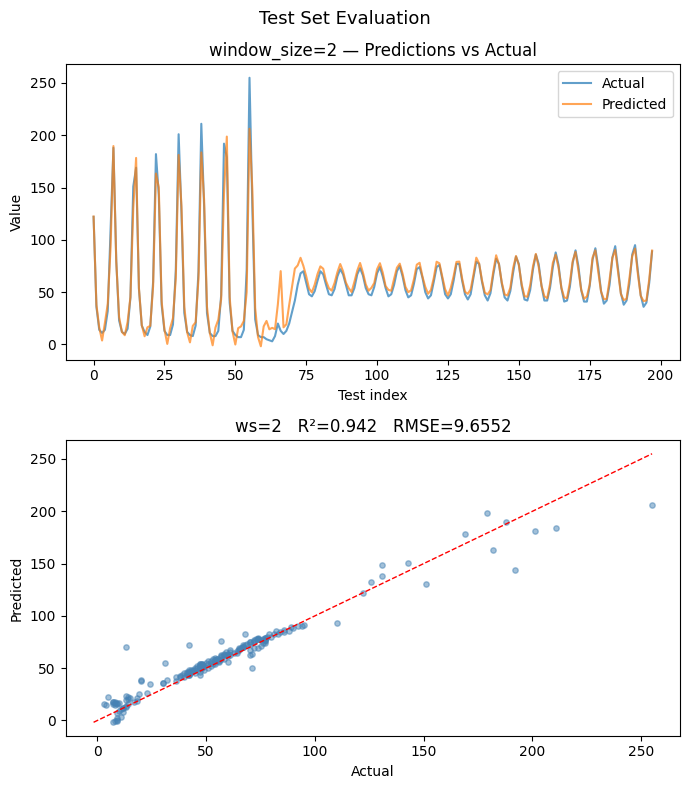

In [44]:
# Re-fit scaler on training data only — same as was used for datasets_raw
# (scaler in memory was overwritten by the interpolated dataset cell)
scaler_raw = MinMaxScaler()
scaler_raw.fit(X_raw.reshape(-1, 1))

# Load and scale test data
X_test_raw = test['Xtest'].flatten()
X_test_scaled = scaler_raw.transform(X_test_raw.reshape(-1, 1)).flatten()

# Evaluate all final models
results = {}
for ws, model in final_models.items():
    X_seq, Y_seq = create_dataset(X_test_scaled, ws)
    X_seq = X_seq.reshape(X_seq.shape[0], X_seq.shape[1], 1)

    preds_scaled = model.predict(X_seq, verbose=0)
    y_true = scaler_raw.inverse_transform(Y_seq.reshape(-1, 1)).flatten()
    y_pred = scaler_raw.inverse_transform(preds_scaled).flatten()

    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_true, y_pred)
    mask = y_true != 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    r2   = r2_score(y_true, y_pred)

    results[ws] = {'y_true': y_true, 'y_pred': y_pred,
                   'mse': mse, 'rmse': rmse, 'mae': mae, 'mape': mape, 'r2': r2}

    print(f"window_size={ws}")
    print(f"  MSE={mse:.4f}  RMSE={rmse:.4f}  MAE={mae:.4f}  MAPE={mape:.2f}%  R²={r2:.4f}\n")

# Side-by-side plots for each model
ws_list = list(final_models.keys())
fig, axes = plt.subplots(2, len(ws_list), figsize=(7 * len(ws_list), 8), squeeze=False)
fig.suptitle('Test Set Evaluation', fontsize=13)

for col, ws in enumerate(ws_list):
    r = results[ws]

    axes[0, col].plot(r['y_true'], label='Actual', alpha=0.7)
    axes[0, col].plot(r['y_pred'], label='Predicted', alpha=0.7)
    axes[0, col].set_title(f'window_size={ws} — Predictions vs Actual')
    axes[0, col].set_xlabel('Test index')
    axes[0, col].set_ylabel('Value')
    axes[0, col].legend()

    lims = [min(r['y_true'].min(), r['y_pred'].min()),
            max(r['y_true'].max(), r['y_pred'].max())]
    axes[1, col].scatter(r['y_true'], r['y_pred'], alpha=0.5, s=15, color='steelblue')
    axes[1, col].plot(lims, lims, 'r--', linewidth=1)
    axes[1, col].set_title(f'ws={ws}   R²={r["r2"]:.3f}   RMSE={r["rmse"]:.4f}')
    axes[1, col].set_xlabel('Actual')
    axes[1, col].set_ylabel('Predicted')

plt.tight_layout()
plt.show()

## Comparison: Raw vs Interpolated Data

Same grid search repeated on the interpolated 1999-point dataset. Results are compared against the raw grid search above.

In [45]:
# # Grid search on interpolated data
# gs_results = []
# gs_early_stop_interp = tf.keras.callbacks.EarlyStopping(
#     monitor='val_loss', patience=5, restore_best_weights=True
# )
# print(f"Running {total} combinations on interpolated data...\n")

# for idx, combo in enumerate(itertools.product(*values), 1):
#     params = dict(zip(keys, combo))
#     ws = params['window_size']
#     d  = datasets[ws]

#     model = Sequential([
#         tf.keras.Input(shape=(ws, 1)),
#         SimpleRNN(params['rnn_units'], activation='tanh'),
#         Dense(1),
#     ])
#     model.compile(
#         optimizer=tf.keras.optimizers.Adam(learning_rate=params['learning_rate']),
#         loss='mse',
#         metrics=['mae'],
#     )
#     hist = model.fit(
#         d['X_train'], d['Y_train'],
#         epochs=100, batch_size=params['batch_size'], verbose=0,
#         validation_split=0.2,
#         callbacks=[gs_early_stop_interp],
#     )
#     val_loss = min(hist.history['val_loss'])
#     val_mae  = min(hist.history['val_mae'])
#     gs_results.append({
#         **params,
#         'val_loss':   val_loss,
#         'val_mae':    val_mae,
#         'epochs_run': len(hist.history['val_loss']),
#     })
#     print(f"[{idx:>2}/{total}] ws={ws}, units={params['rnn_units']:>3}, "
#           f"lr={params['learning_rate']}, bs={params['batch_size']:>2} "
#           f"-> val_loss={val_loss:.4f}, val_mae={val_mae:.4f}")

# gs_df = pd.DataFrame(gs_results).sort_values('val_loss').reset_index(drop=True)
# print("\nTop 10 configurations (interpolated):")
# print(gs_df.head(10).to_string(index=False))

In [46]:
# best_interp = gs_df.iloc[0]
# best_raw    = gs_df_raw.iloc[0]

# # Side-by-side summary table
# print(f"{'':30} {'Interpolated':>15}  {'Raw':>15}")
# print("=" * 65)
# for label, vi, vr in [
#     ('Best val_loss',    f"{best_interp.val_loss:.4f}",        f"{best_raw.val_loss:.4f}"),
#     ('Best val_mae',     f"{best_interp.val_mae:.4f}",         f"{best_raw.val_mae:.4f}"),
#     ('window_size',      str(int(best_interp.window_size)),    str(int(best_raw.window_size))),
#     ('rnn_units',        str(int(best_interp.rnn_units)),      str(int(best_raw.rnn_units))),
#     ('learning_rate',    str(best_interp.learning_rate),       str(best_raw.learning_rate)),
#     ('batch_size',       str(int(best_interp.batch_size)),     str(int(best_raw.batch_size))),
# ]:
#     print(f"{label:30} {vi:>15}  {vr:>15}")

# # Visual comparison: val_loss distribution per window size
# fig, axes = plt.subplots(1, 2, figsize=(13, 5))
# fig.suptitle('Grid Search: Interpolated vs Raw — val_loss by window size', fontsize=12)

# colors = ['steelblue', 'coral']
# for ax, df, label, color in zip(
#     axes, [gs_df, gs_df_raw], ['Interpolated', 'Raw'], colors
# ):
#     grouped = df.groupby('window_size')['val_loss'].agg(['mean', 'min', 'max']).reset_index()
#     x = range(len(grouped))
#     ax.bar(x, grouped['mean'], color=color, alpha=0.7, label='mean val_loss')
#     ax.errorbar(x, grouped['mean'],
#                 yerr=[grouped['mean'] - grouped['min'], grouped['max'] - grouped['mean']],
#                 fmt='none', color='black', capsize=5, label='min / max')
#     ax.set_xticks(x)
#     ax.set_xticklabels(grouped['window_size'])
#     ax.set_xlabel('window_size')
#     ax.set_ylabel('val_loss (MSE)')
#     ax.set_title(label)
#     ax.legend(fontsize=8)

# plt.tight_layout()
# plt.show()

### References

- https://medium.com/@rakesh.ganya28/building-sequential-models-with-rnn-recurrent-neural-networks-using-keras-api-d32a83d7b6b5